# вариант 1

Построение прогноза на 8 месяцев методом сезонной декомпозиции.

Рассматриваемый ряд: коэффициент загрузки гостиниц, chicago central business district.

Подход к решению:
- выделяем тренд, сезонность и случайную часть;
- убираем сезонность;
- на очищенном ряде строим линейный тренд;
- возвращаем сезонность и получаем прогноз.

В этом варианте анализируется доля занятых номеров в гостиницах центрального делового района Чикаго.


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display

# делаем графики чуть аккуратнее
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format


In [2]:
# задаем параметры текущего варианта
variant_number = 1
column = 'x1'
series_title = 'коэффициент загрузки гостиниц, chicago central business district'
series_unit = '%'

month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12,
}

month_names_ru = {
    1: 'январь',
    2: 'февраль',
    3: 'март',
    4: 'апрель',
    5: 'май',
    6: 'июнь',
    7: 'июль',
    8: 'август',
    9: 'сентябрь',
    10: 'октябрь',
    11: 'ноябрь',
    12: 'декабрь',
}


## загружаем и подготавливаем данные

In [3]:
data = pd.read_csv('data.csv', sep=';', dtype=str)

data['month'] = data['date1'].map(month_map)
data['date'] = pd.to_datetime(
    dict(year=data['date2'].astype(int), month=data['month'], day=1)
)

data[column] = pd.to_numeric(
    data[column].str.replace(',', '.', regex=False),
    errors='coerce'
)

series = data.set_index('date')[column]
train = series.dropna()
future_dates = series[series.isna()].index

print(f'вариант: {variant_number}')
print(f'столбец: {column}')
print(f'известных наблюдений: {len(train)}')
print(f'месяцев для прогноза: {len(future_dates)}')

display(data[['date', column]].head())
display(data[['date', column]].tail(12))


вариант: 1
столбец: x1
известных наблюдений: 112
месяцев для прогноза: 8


,date,x1
0,1994-01-01,44.30
1,1994-02-01,54.70
2,1994-03-01,61.90
3,1994-04-01,69.10
4,1994-05-01,70.80


,date,x1
108,2003-01-01,51.60
109,2003-02-01,52.70
110,2003-03-01,65.00
111,2003-04-01,69.00
112,2003-05-01,NaN
113,2003-06-01,NaN
114,2003-07-01,NaN
115,2003-08-01,NaN
116,2003-09-01,NaN
117,2003-10-01,NaN


## смотрим на исходный временной ряд

сначала полезно просто посмотреть на график. так легче заметить общий рост и повторяющиеся сезонные волны.


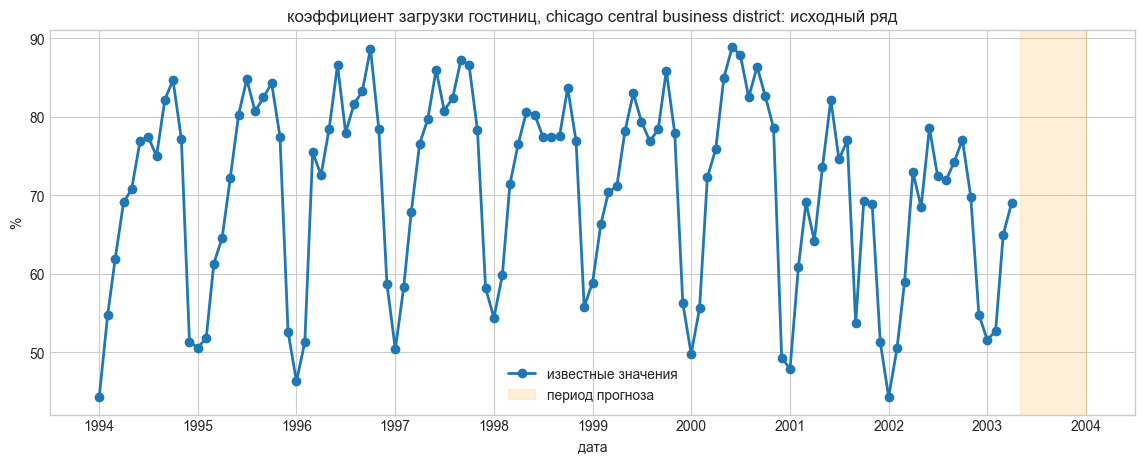

In [4]:
# строим график известных значений
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, label='известные значения')

# подсвечиваем участок, который будем прогнозировать
if len(future_dates) > 0:
    plt.axvspan(
        future_dates[0],
        future_dates[-1] + pd.offsets.MonthEnd(1),
        color='orange',
        alpha=0.15,
        label='период прогноза'
    )

plt.title(f'{series_title}: исходный ряд')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## делаем сезонную декомпозицию

используем мультипликативную модель:

`значение = тренд * сезонность * случайная часть`

она хорошо подходит здесь, потому что все значения положительные, а сезонность удобно трактовать как коэффициент относительно тренда.


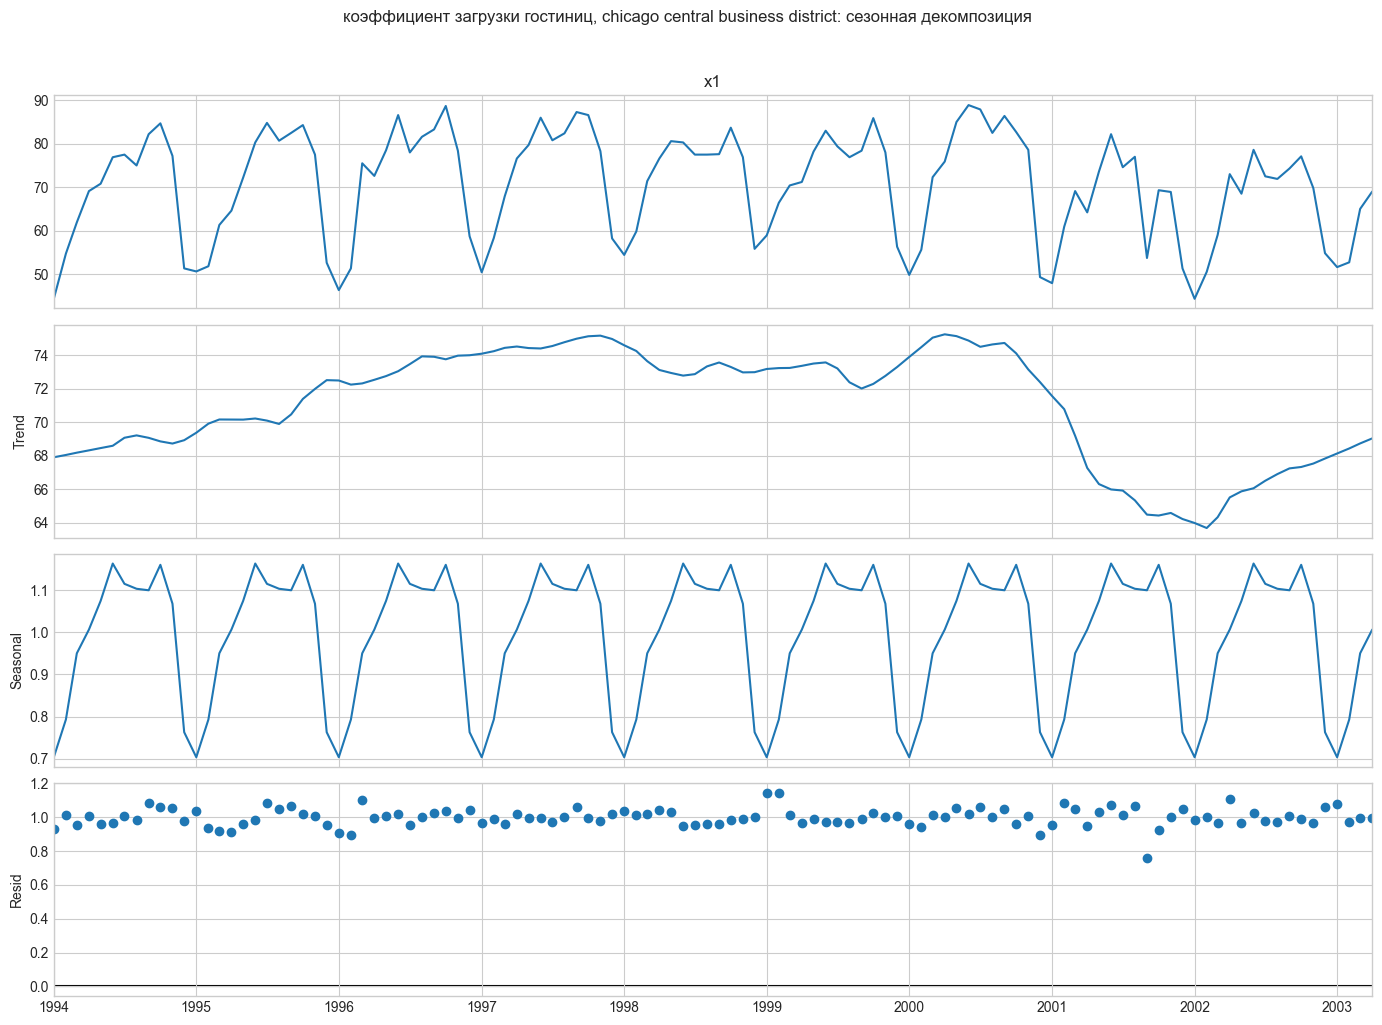

In [5]:
# раскладываем ряд на компоненты

decomposition = seasonal_decompose(
    train,
    model='multiplicative',
    period=12,
    extrapolate_trend='freq'
)

# показываем графики компонентов
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle(f'{series_title}: сезонная декомпозиция', y=1.02)
plt.tight_layout()
plt.show()


## выписываем сезонные коэффициенты

эти коэффициенты показывают, во сколько раз месяц обычно выше или ниже тренда.
- коэффициент больше `1` означает месяц выше тренда;
- коэффициент меньше `1` означает месяц ниже тренда.


In [6]:
# усредняем сезонные коэффициенты по каждому месяцу
seasonal_pattern = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()

# оформляем таблицу в удобном виде
seasonal_table = pd.DataFrame({
    'месяц': [month_names_ru[m] for m in seasonal_pattern.index],
    'сезонный коэффициент': seasonal_pattern.values
})

display(seasonal_table)


,месяц,сезонный коэффициент
0,январь,0.70
1,февраль,0.79
2,март,0.95
3,апрель,1.01
4,май,1.07
5,июнь,1.16
6,июль,1.12
7,август,1.10
8,сентябрь,1.10
9,октябрь,1.16


## убираем сезонность и строим тренд

делим ряд на сезонную компоненту, чтобы получить более ровный ряд без колебаний по месяцам. после этого строим простой линейный тренд.


уравнение тренда: y = 72.444 + -0.026 * t


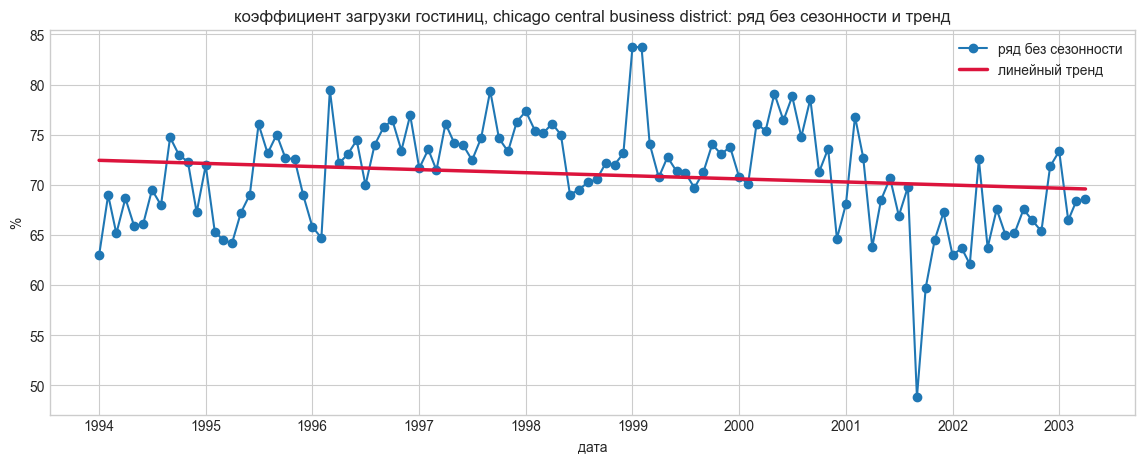

In [7]:
# убираем сезонность

deseasonalized = train / decomposition.seasonal

# кодируем время числами 0, 1, 2, ...
time_index = np.arange(len(deseasonalized))

# строим линейный тренд по формуле прямой
slope, intercept = np.polyfit(time_index, deseasonalized.values, 1)
trend_line = intercept + slope * time_index

print(f'уравнение тренда: y = {intercept:.3f} + {slope:.3f} * t')

# показываем ряд без сезонности и тренд
plt.figure(figsize=(14, 5))
plt.plot(train.index, deseasonalized.values, marker='o', label='ряд без сезонности')
plt.plot(train.index, trend_line, color='crimson', linewidth=2.5, label='линейный тренд')
plt.title(f'{series_title}: ряд без сезонности и тренд')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## строим прогноз на 8 месяцев

теперь продолжаем тренд вперёд, а затем возвращаем сезонность для каждого будущего месяца.


In [8]:
# продолжаем тренд на будущие месяцы
future_time_index = np.arange(len(deseasonalized), len(deseasonalized) + len(future_dates))
future_trend = intercept + slope * future_time_index

# подбираем сезонные коэффициенты для будущих месяцев
future_season = np.array([seasonal_pattern[date.month] for date in future_dates])

# получаем итоговый прогноз
forecast = future_trend * future_season

# собираем красивую таблицу прогноза
forecast_table = pd.DataFrame({
    'дата': [f"{month_names_ru[date.month]} {date.year}" for date in future_dates],
    f'прогноз, {series_unit}': np.round(forecast, 2)
})

display(forecast_table)


,дата,"прогноз, %"
0,май 2003,74.76
1,июнь 2003,80.89
2,июль 2003,77.51
3,август 2003,76.67
4,сентябрь 2003,76.39
5,октябрь 2003,80.56
6,ноябрь 2003,74.12
7,декабрь 2003,52.93


## смотрим итоговый график

на одном графике покажем исходные данные, модель на известной части ряда и наш прогноз.


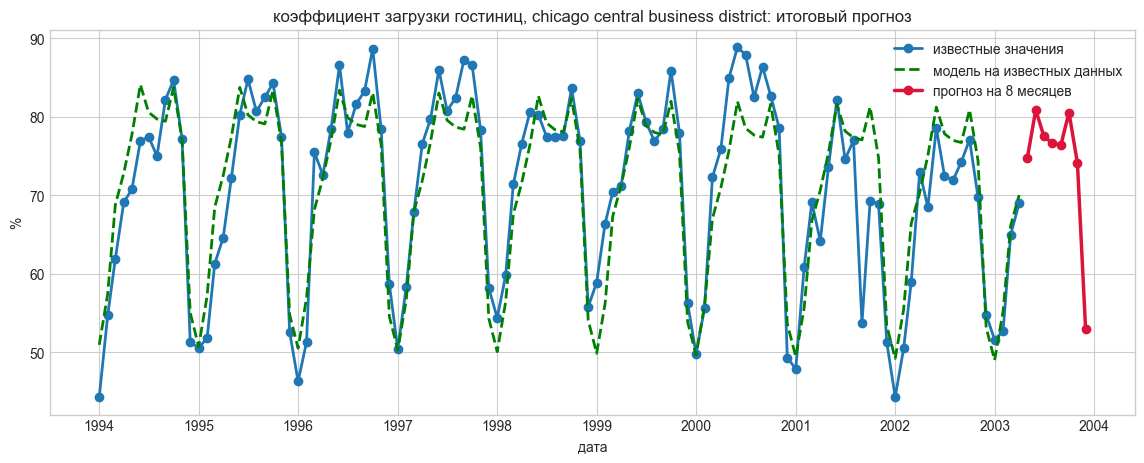

In [9]:
# восстанавливаем модель на известной части ряда
fitted = trend_line * np.array([seasonal_pattern[date.month] for date in train.index])

# строим итоговый график
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, label='известные значения')
plt.plot(train.index, fitted, linestyle='--', linewidth=2, color='green', label='модель на известных данных')
plt.plot(future_dates, forecast, marker='o', linewidth=2.5, color='crimson', label='прогноз на 8 месяцев')
plt.title(f'{series_title}: итоговый прогноз')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## собираем итоговую таблицу

заполним последние 8 пустых месяцев рассчитанными значениями и посмотрим на финальный хвост ряда.


In [10]:
# подставляем прогноз вместо пропусков
result = data[['date', column]].copy()
result['итоговое значение'] = result[column]
result.loc[result['итоговое значение'].isna(), 'итоговое значение'] = forecast

# добавляем удобную подпись месяца
result['месяц'] = result['date'].apply(lambda d: f"{month_names_ru[d.month]} {d.year}")

# показываем последние 12 месяцев ряда
final_table = result[['месяц', 'итоговое значение']].tail(12).reset_index(drop=True)
display(final_table)


,месяц,итоговое значение
0,январь 2003,51.60
1,февраль 2003,52.70
2,март 2003,65.00
3,апрель 2003,69.00
4,май 2003,74.76
5,июнь 2003,80.89
6,июль 2003,77.51
7,август 2003,76.67
8,сентябрь 2003,76.39
9,октябрь 2003,80.56


## вывод

В работе построен прогноз на 8 месяцев методом сезонной декомпозиции. Для расчёта были выделены трендовая и сезонная компоненты ряда, после чего получены прогнозные значения для будущих месяцев.
